# Import Libraries

In [86]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
from wordcloud import WordCloud

# Upload Dataset

In [60]:
train = pd.read_csv(
"/content/train (1).csv"
)

test = pd.read_csv(
  "/content/test (1).csv"
)

sample = pd.read_csv(
"/content/sample_submission (1).csv"
)

# Read Dataset

In [61]:
print(f"Train Shape  : {train.shape}")

print(f"Test Shape   : {test.shape}")

print(f"Sample Shape : {sample.shape}")

train.head()

Train Shape  : (2000, 8)
Test Shape   : (500, 7)
Sample Shape : (500, 2)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# Data Information

In [62]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


# Missing Values

In [63]:
missing = train.isna().sum()
print(f"Total number of missing values in our training dataset - {missing.sum()}")

Total number of missing values in our training dataset - 0


# Visualization

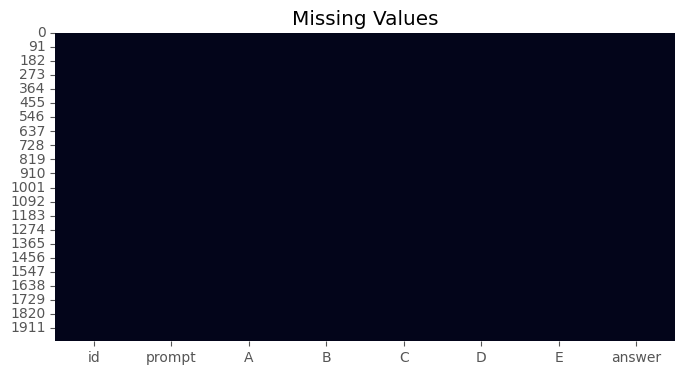

In [64]:
import seaborn as sns
plt.figure(figsize=(8,4))
sns.heatmap(train.isna(),cbar=False)
plt.title("Missing Values")
plt.show()

# Duplicate Rows

In [65]:
print(f"Duplicate Rows : {train.duplicated().sum()}")

Duplicate Rows : 0


# Class Distribution

In [66]:
train['answer'].value_counts()

,count
answer,
B,490
C,459
A,369
D,358
E,324


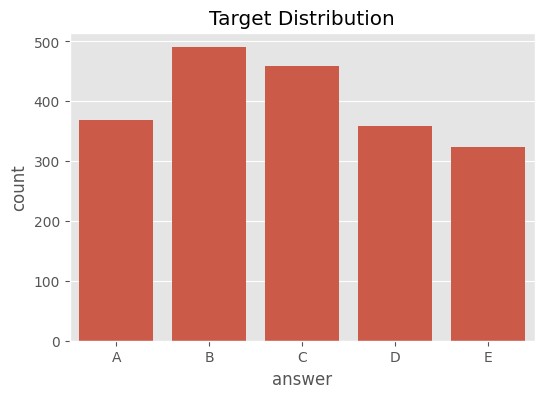

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(data = train , x="answer",order=sorted(train['answer'].unique()))
plt.title("Target Distribution")
plt.show()

# Prompt Length

In [68]:
train['prompt_length'] = train['prompt'].apply(lambda x: len(x.split()))

## Statistics


In [69]:
train['prompt_length'].describe()

,prompt_length
count,2000.00000
mean,18.14650
std,6.78189
min,3.00000
25%,14.00000
50%,17.00000
75%,22.00000
max,51.00000


# Histogram


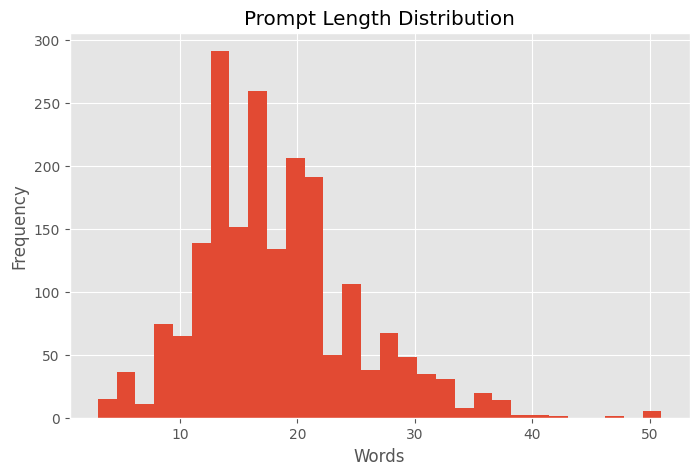

In [70]:
plt.figure(figsize=(8,5))

plt.hist(train["prompt_length"],bins=30)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Prompt Length Distribution")

plt.show()

# Option Lengths

In [71]:
options = ["A","B","C","D","E"]
for col in options :
  train[col+"_length"] = train[col].apply(lambda x: len(x.split()))

train

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,22,51,41,38,31,31
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,5,62,52,52,62,62
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,27,1,1,1,1,1
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,19,51,41,38,31,31
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,15,36,36,36,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,What is the piezoelectric strain coefficient f...,d = 1.9·10‑12 m/V,d = 3.1·10‑12 m/V,d = 4.2·10‑12 m/V,d = 2.5·10‑12 m/V,d = 5.8·10‑12 m/V,B,10,4,4,4,4,4
1996,1997,Identify the correct statement: What is the sy...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,A device used to demonstrate a neuro-inspired ...,E,16,17,17,17,17,17
1997,1998,Determine the correct option: What does Earnsh...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges cannot be mainta...,A collection of point charges can be maintaine...,D,13,22,22,27,22,22
1998,1999,Identify the correct statement: What is the re...,The atmosphere is a mechanism that is only inf...,"The atmosphere possesses both chaos and order,...",The atmosphere is a structure that is only inf...,The atmosphere is a completely chaotic mechani...,The atmosphere is a completely ordered structu...,B,37,19,17,19,12,12


## Statistics

In [72]:
train[[c+"_length" for c in options]].describe()

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,26.146000,26.516000,26.54950,25.999500,26.187000
std,17.249651,18.653893,17.20987,17.098909,17.852658
min,1.000000,1.000000,1.00000,1.000000,1.000000
25%,13.000000,12.000000,14.75000,15.000000,13.000000
50%,22.000000,23.000000,24.00000,22.000000,23.000000
75%,37.000000,36.000000,36.00000,36.000000,36.000000
max,81.000000,118.000000,82.00000,78.000000,105.000000


## Boxplot

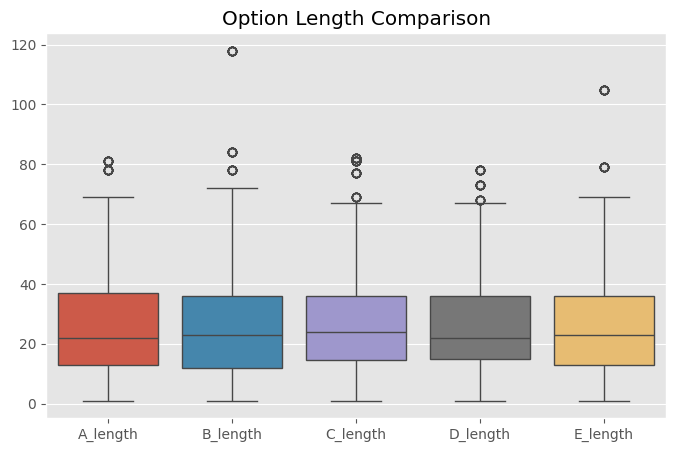

In [73]:
length_cols=[c+"_length" for c in options]

plt.figure(figsize=(8,5))

sns.boxplot(data=train[length_cols])

plt.title("Option Length Comparison")

plt.show()

# Longest Questions

In [75]:
train.nlargest(5 , "prompt_length")[["prompt","answer"]]

,prompt,answer
1484,Select the most accurate option: What is one o...,C
1980,Identify the correct statement: What is one of...,C
574,Choose the correct answer: What is one of the ...,C
1164,Determine the correct option: What is one of t...,C
1611,Determine the correct option: What is one of t...,C


## Shrtest Question

In [77]:
train.nsmallest(5 , "prompt_length")[["prompt","answer"]]

,prompt,answer
479,What is emissivity?,C
1398,What is resistivity?,C
1510,What is organography?,B
34,What is a pycnometer?,D
319,What is a light-year?,B


# Word Cloud

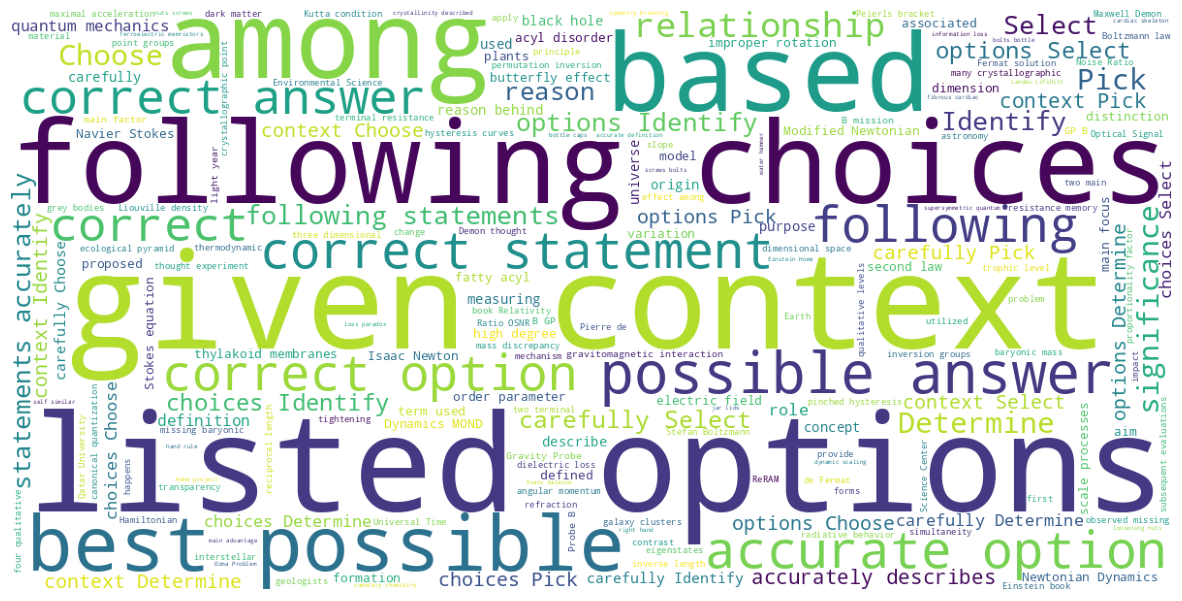

In [87]:
text=" ".join(train["prompt"])

wc=WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wc)

plt.axis("off")

plt.show()

## Sample Questions

In [88]:
for i in range(3):

    print("="*100)

    print(train.loc[i,"prompt"])

    print()

    for option in ["A","B","C","D","E"]:

        print(option,":",train.loc[i,option])

    print()

    print("Correct Answer :",train.loc[i,"answer"])

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

A : Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B : Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C : Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D : Martin Heidegger believes that the relationship be

# Key Observations

- Dataset contains 2,000 training samples and 500 test samples.
- No missing values were found.
- Duplicate rows (if any) were identified.
- Class distribution is reasonably balanced.
- Prompt lengths vary across samples.
- Option lengths are generally short.
- The dataset is suitable for transformer-based and deep learning models.

## Next Step

Text preprocessing and tokenization.